In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
jobs = pd.read_csv(r"C:\Users\cbala\OneDrive\Desktop\RecruitSmart\data\jobs_cleaned.csv")

feature_matrix = pd.read_csv(r"C:\Users\cbala\OneDrive\Desktop\RecruitSmart\flattened_feature_matrix.csv")

In [5]:
jobs["required_experience"].value_counts()

required_experience
Mid-Senior level    3809
Entry level         2697
Associate           2297
Not Applicable      1116
Director             389
Internship           381
Executive            141
Name: count, dtype: int64

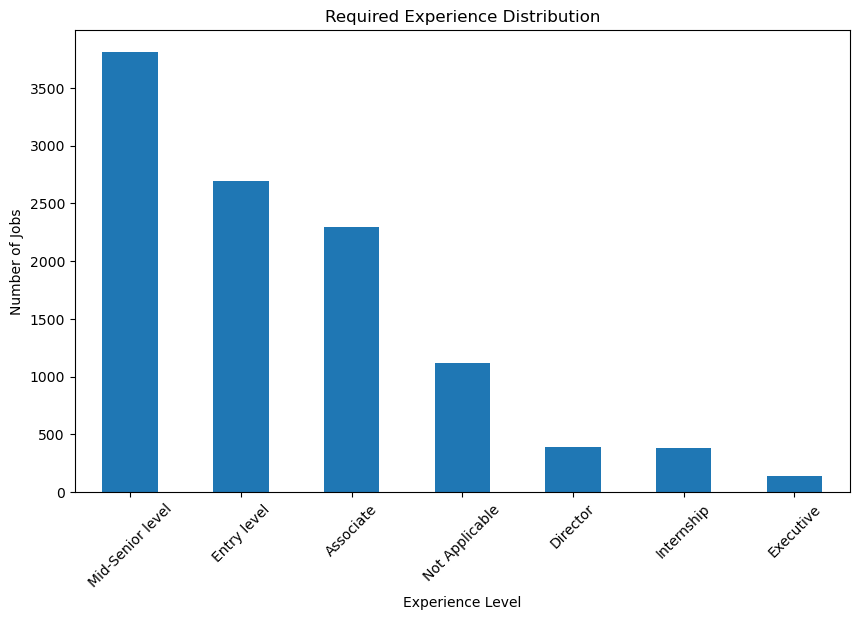

In [7]:
plt.figure(figsize=(10,6))

jobs["required_experience"].value_counts().plot(kind="bar")

plt.title("Required Experience Distribution")
plt.xlabel("Experience Level")
plt.ylabel("Number of Jobs")

plt.xticks(rotation=45)

plt.show()

In [9]:
feature_matrix["match_relevance_score"].describe()

count    1000.000000
mean        0.671900
std         0.250166
min         0.200000
25%         0.500000
50%         0.900000
75%         0.900000
max         0.900000
Name: match_relevance_score, dtype: float64

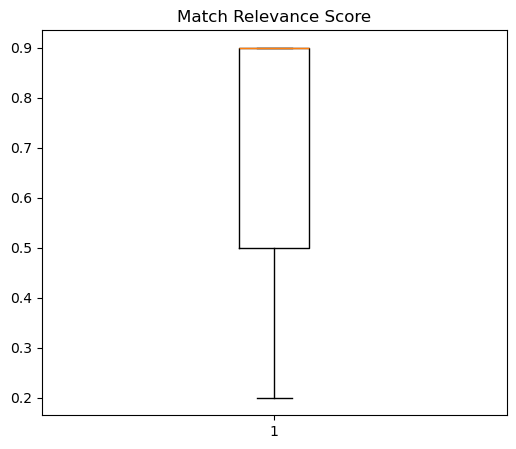

In [11]:
plt.figure(figsize=(6,5))

plt.boxplot(feature_matrix["match_relevance_score"])

plt.title("Match Relevance Score")

plt.show()

In [13]:
Q1 = feature_matrix["match_relevance_score"].quantile(0.25)

Q3 = feature_matrix["match_relevance_score"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

outliers = feature_matrix[
    (feature_matrix["match_relevance_score"] < lower) |
    (feature_matrix["match_relevance_score"] > upper)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 0


In [15]:
feature_matrix_filtered = feature_matrix[
    (feature_matrix["match_relevance_score"] >= lower) &
    (feature_matrix["match_relevance_score"] <= upper)
]

print(feature_matrix_filtered.shape)

(1000, 8)


In [17]:
feature_matrix.columns

Index(['application_id', 'job_id', 'title', 'required_experience', 'person_id',
       'name', 'total_skills', 'match_relevance_score'],
      dtype='object')

In [19]:
final_features = feature_matrix[[
    "job_id",
    "person_id",
    "title",
    "required_experience",
    "total_skills",
    "match_relevance_score"
]]

final_features.head()

,job_id,person_id,title,required_experience,total_skills,match_relevance_score
0,15796,20608,Beauty & Fragrance consultants needed,NaN,19,0.5
1,861,37600,Retail Territory Merchandiser,NaN,113,0.9
2,5391,51921,Inside Sales Rep,Associate,66,0.9
3,11965,28530,Cities Project Manager,NaN,26,0.5
4,11285,35955,Digital Procurement Assistant,Entry level,58,0.9


In [21]:
final_features.to_csv(
    r"C:\Users\cbala\OneDrive\Desktop\RecruitSmart\final_feature_set.csv",
    index=False
)

print("Final Feature Set Saved Successfully!")

Final Feature Set Saved Successfully!
